<a href="https://colab.research.google.com/github/kukanmani06/Internship_Projects/blob/main/Time_Series_Forecasting_Air_Passengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
# Read Raw Dataset
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [51]:
data=pd.read_csv("https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/AirPassengers.csv")

In [52]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [53]:
data.dtypes

,0
Month,object
#Passengers,int64


In [54]:
data['Month']=pd.to_datetime(data['Month'],format='%Y-%m')

In [55]:
data=data.set_index('Month')

In [56]:
data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [57]:
data.isnull().sum()

,0
#Passengers,0


##### 3. Time Series Plots
    * A visual observation of time series plots / histogram can give an insight into the presence of trend and seasonality in the data.

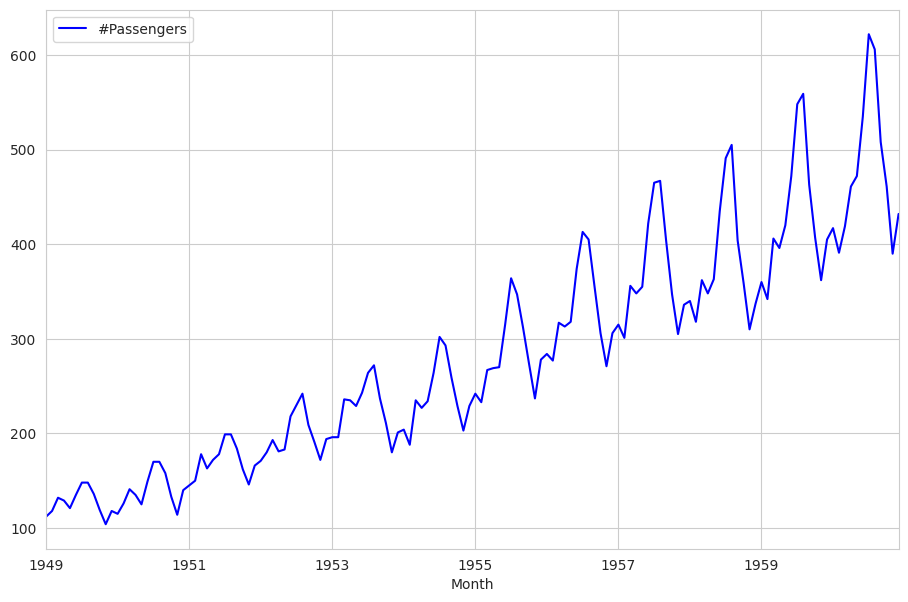

In [58]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 11, 7

sns.set_style('whitegrid')
data.plot(color = 'blue')
plt.show()

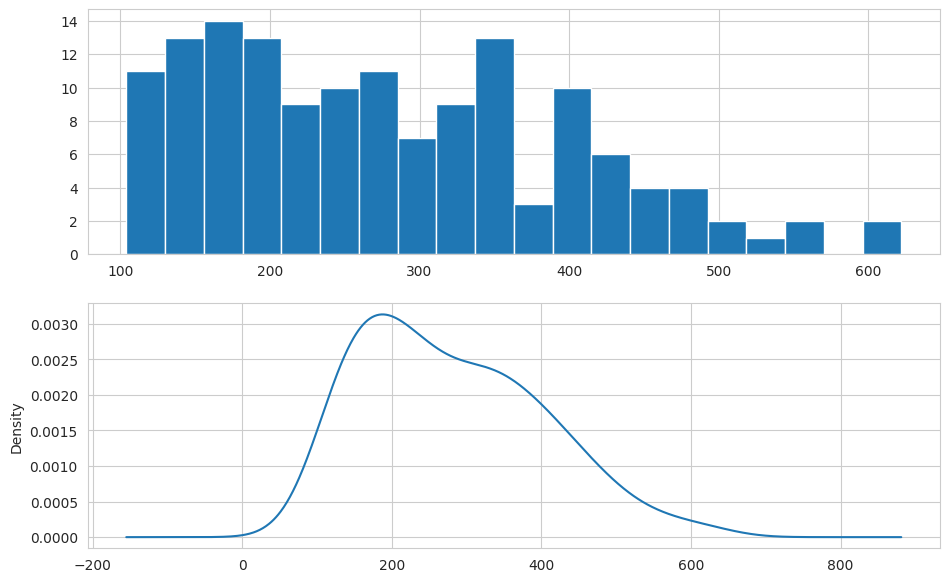

In [59]:
plt.subplot(2, 1, 1)
plt.hist(data['#Passengers'], bins = 20)
plt.subplot(2, 1, 2)
data['#Passengers'].plot(kind = 'kde')
plt.show()

Reviewing plots of the density observations which can provide further insight into structure of the data.

    * The distribution is not perfectly Gaussian (normal distribution).
    * The distribution is right skewed.
    * Transformations might be useful prior to modeling.

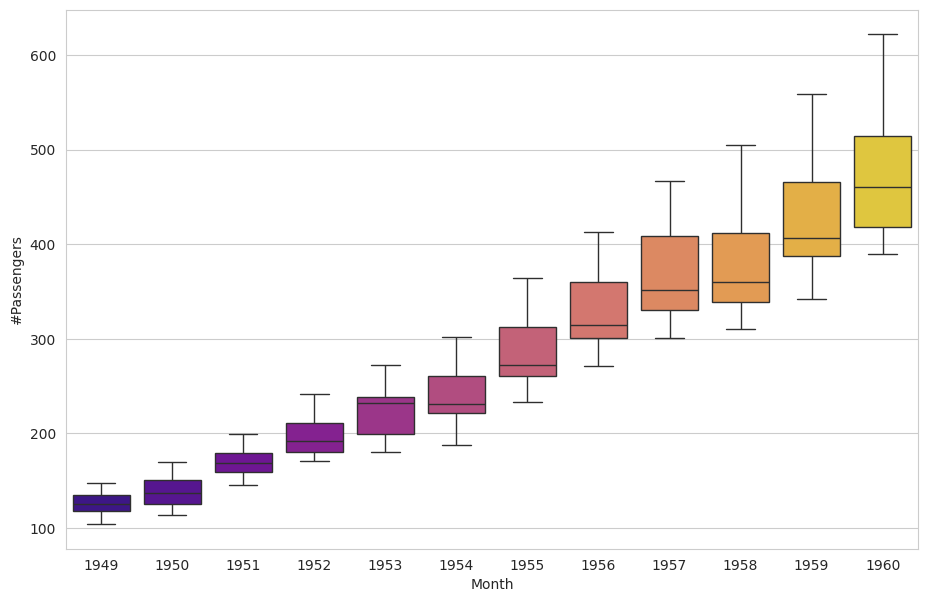

In [60]:
sns.boxplot(x = data.index.year, y = data['#Passengers'], palette='plasma')
plt.show()

* Median values accross years confirms upward trends.
* Steady increase in the spread, middle 50th percentile of the data over time.
* Model considering seasonality might work well.

In [61]:
ts=data['#Passengers']

##### Time Series Decomposition
* Time Series Decomposition is a technique to seperate a time series into its fundamental components.
* Trend (T) : The long-term direction (upward, downward or flat [no-trend])
* Seasonality (S) : Regular repeating patterns at fixed intervals (e.g. monthly, yearly)
* Residual (R) : Random noise or irregularities not explained by trend or seasonality.

##### Type of Decomposition Models
1. Additive Model
  * Yt = Tt + St + Rt
2. Multiplicative
  * Yt=Tt * St * Rt

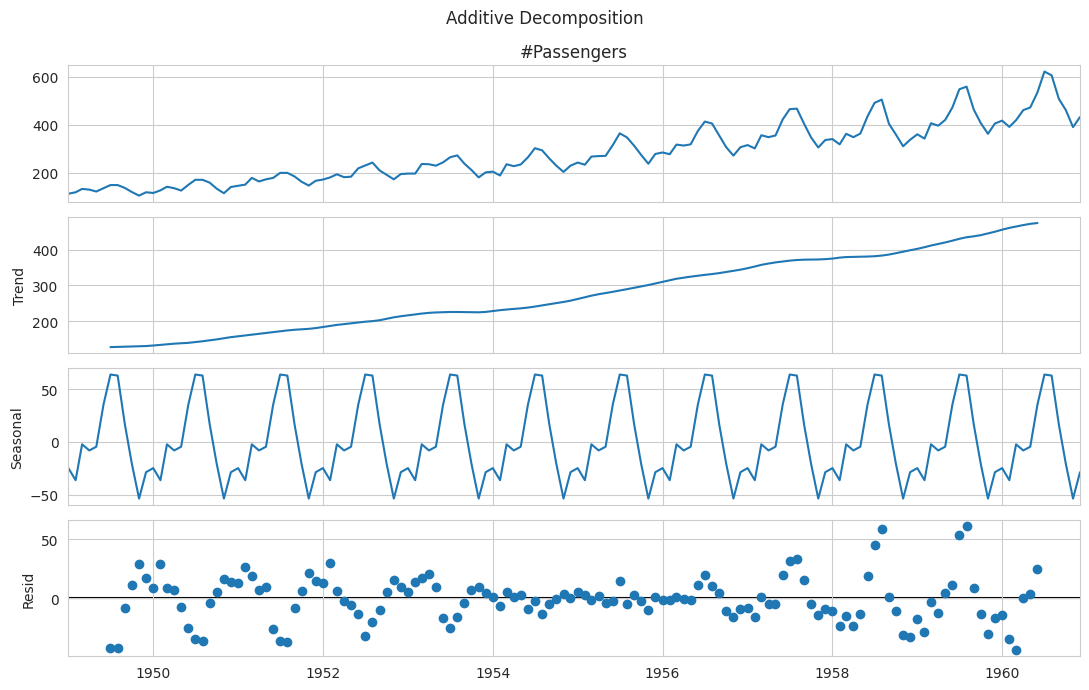

In [62]:
from statsmodels.tsa.seasonal import seasonal_decompose
result_add = seasonal_decompose(ts, model='additive', period = 12)
result_add.plot()
plt.suptitle("Additive Decomposition")
plt.tight_layout()
plt.show()

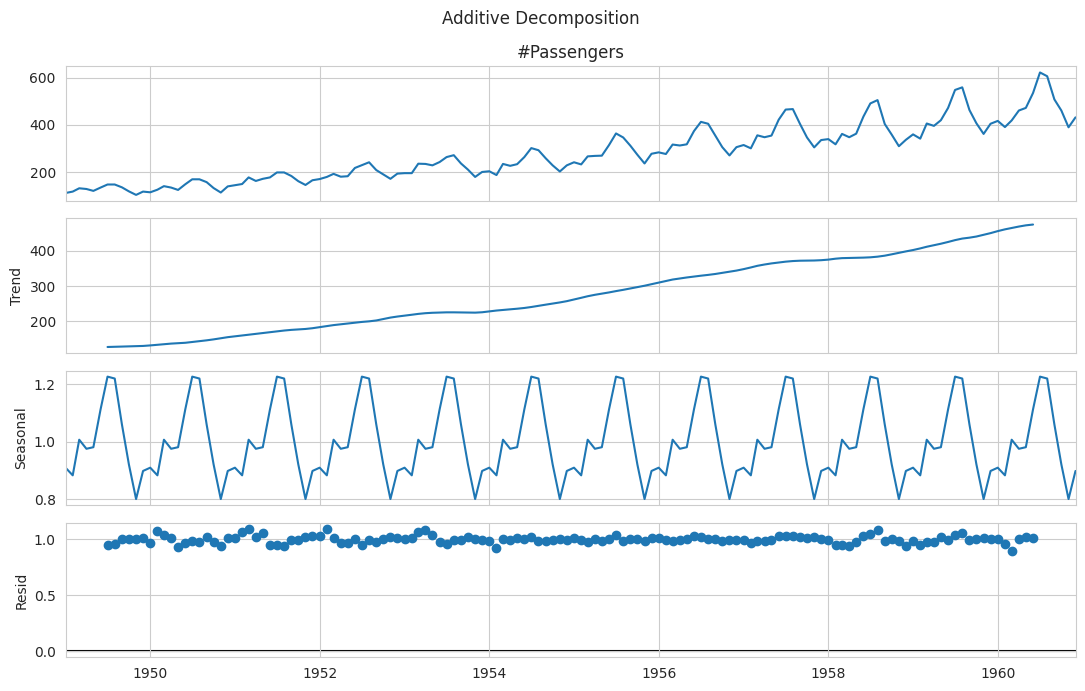

In [63]:
result_add = seasonal_decompose(ts, model='multiplicative', period = 12)
result_add.plot()
plt.suptitle("Additive Decomposition")
plt.tight_layout()
plt.show()

6.Test for Stationarity
  *   Plotting Rolling Statistics
  *   Augmented Dicky Fuller Test

In [64]:
rollmean = ts.rolling(window = 15).mean()
rollstd = ts.rolling(window = 15).std()

In [65]:
rollmean.head(25)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


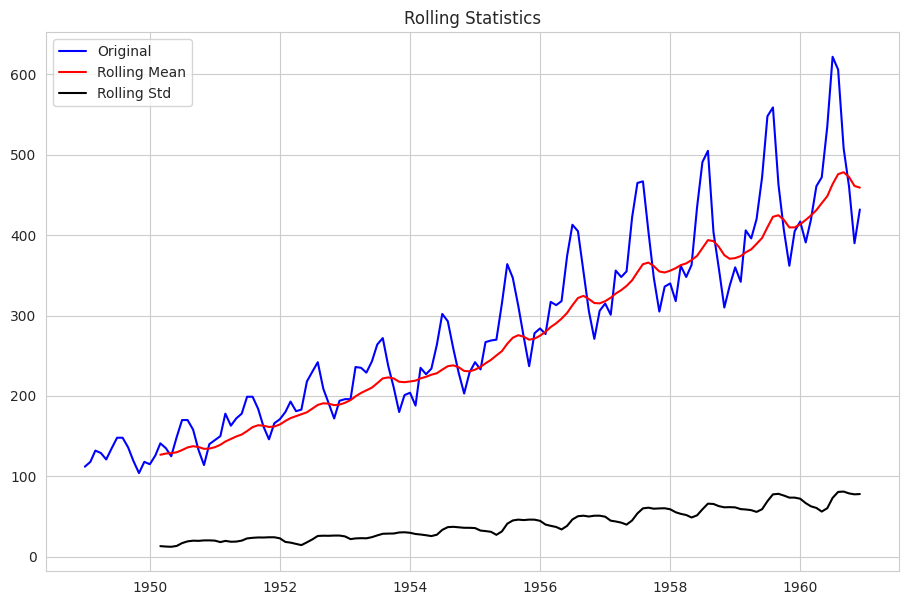

In [66]:
plt.plot(data,color='blue',label='Original')
plt.plot(rollmean,color='red',label='Rolling Mean')
plt.plot(rollstd,color='black',label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Statistics')
plt.show()

Augmented Dickey Fuller Test
 *  The intution behind the test is that if the series is integrated then the lagged level of the series y(t-1) will provide no relevant information in predicting the change in y(t)
* Null Hypothesis(H0) that time series is not stationary.
* Alternative Hypothesis(H1) that time series is stationary.

In [67]:
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-Fuller Test:")
dftest = adfuller(ts)
dftest

Results of Dickey-Fuller Test:


(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [68]:
dfoutput = pd.Series(dftest[0:4], index = ['Test Statsitic','p-value','#Lags Used','Number of Observations Used'])
for key, value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

Test Statsitic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [69]:
if dfoutput['p-value'] <= 0.05:
    print("We reject null hypothesis, time series is stationary for sample data.")
if dfoutput['p-value'] > 0.05:
    print("We failed to reject null hypothesis, time series is not stationary for sample data.")

We failed to reject null hypothesis, time series is not stationary for sample data.


In [70]:
def test_stationarity(timeseries):
  rollmean = timeseries.rolling(window = 15).mean()
  rollstd = timeseries.rolling(window = 15).std()
  plt.plot(data, color = 'blue', label = 'Original')
  plt.plot(rollmean, color = 'red', label = 'Rolling Mean')
  plt.plot(rollstd, color = 'black', label = 'Rolling Std')
  plt.legend(loc = 'best')
  plt.title('Rolling Statistics')
  plt.show()
  dftest = adfuller(timeseries)
  dfoutput = pd.Series(dftest[0:4], index = ['Test Statsitic','p-value','#Lags Used','Number of Observations Used'])
  for key, value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
  print(dfoutput)

#### How to make a Time Series stationary?

Most of the real life datasets will exhibit non stationarity.

There are multiple ways to make a time series stationary:

- Transformation
    - Log transformation
    - Square root transformation
    - Box cox transformation
    - Exponential transformation

- Differencing: Differencing is carried out to get rid of varying mean due to trend. In this difference in consecutive terms in the time series is computed. Mathematically it can be represented as :
                  yt = yt - y(t-1)
                  where yt is the value at time t.
    - Seasonal differencing: In case of presence of seasonality in the data, seasonal differencing can be carried out. In seasonal differencing, we calculate the difference between observation and previous observation of the same season. For example, an observation taken on a Monday is subtracted from that taken on previous Monday or that taken for week1 of a month is subtracted from week  of the previous month. Mathematically it can be represented as:

                   yt‘ = yt – y(t-n)
                   where n is the season length
- Smoothing
- Decomposition

In [71]:
ts_log = np.log(ts)

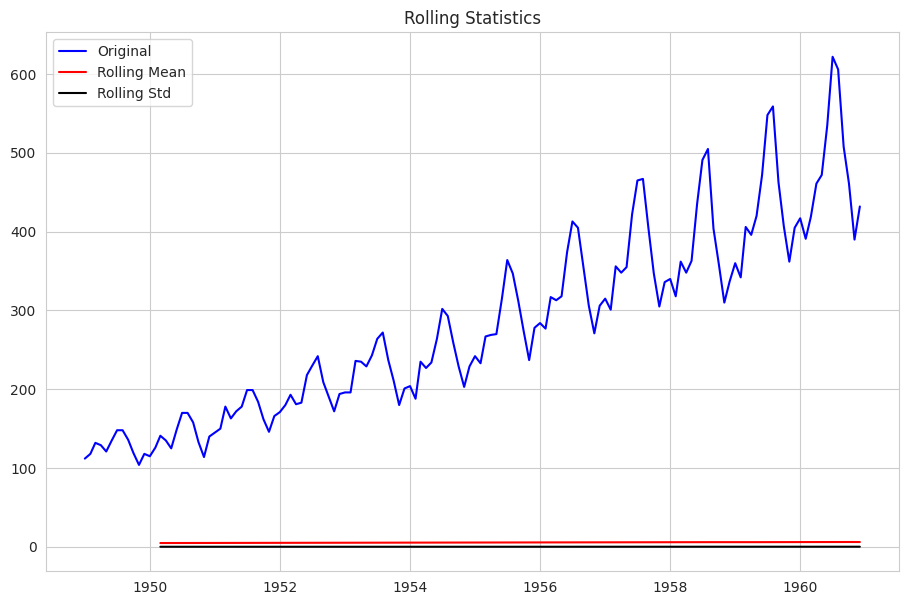

Test Statsitic                  -1.717017
p-value                          0.422367
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [72]:
test_stationarity(ts_log)

In [73]:
ts_diff = ts - ts.shift(1)

In [74]:
ts_diff.head()

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0


Log Differencing


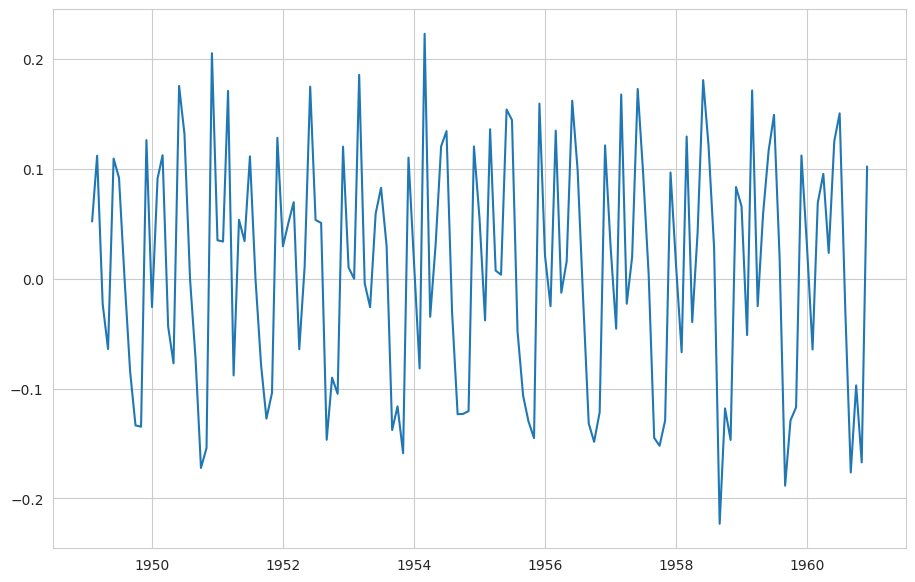

In [75]:
ts_log_diff = ts_log - ts_log.shift(1)
plt.plot(ts_log_diff)
plt.show()

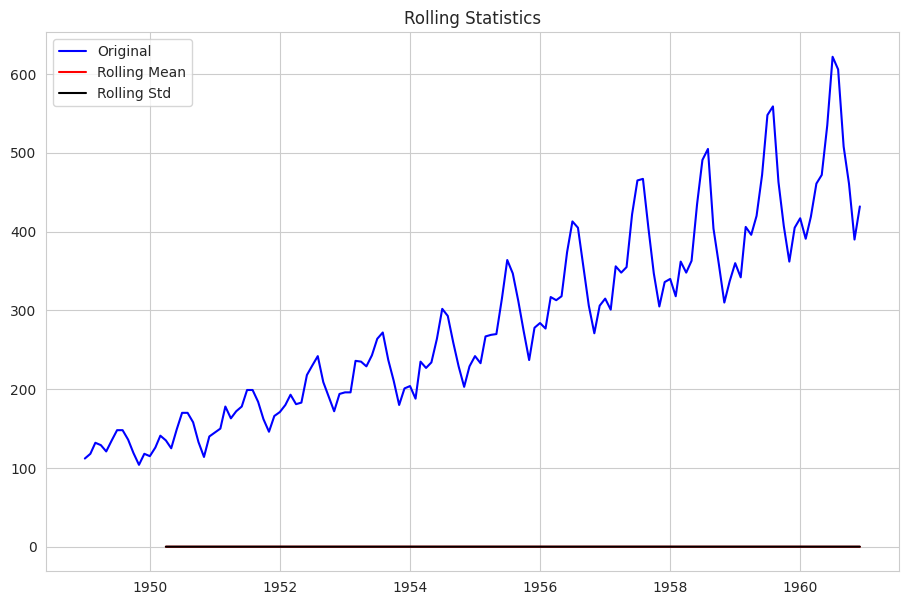

Test Statsitic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


In [76]:
ts_log_diff.dropna(inplace=True)
test_stationarity(ts_log_diff)

In [77]:
movingavg = ts_log.rolling(window=15).mean()
movingstd = ts_log.rolling(window=15).std()

In [78]:
ts_log_mv_diff = ts_log - movingavg
ts_log_mv_diff.dropna(inplace=True)


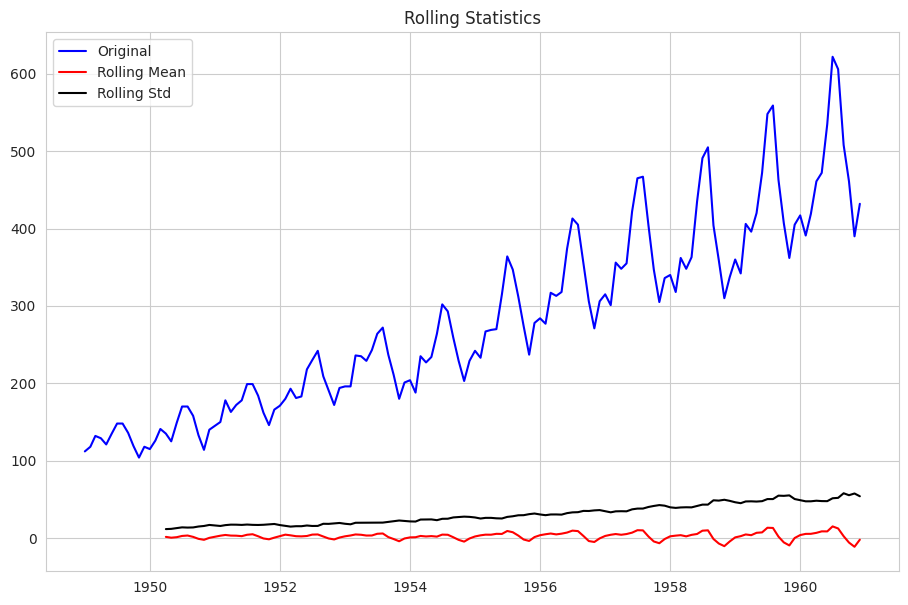

Test Statsitic                  -2.829267
p-value                          0.054213
#Lags Used                      12.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [79]:
ts_diff.dropna(inplace=True)
test_stationarity(ts_diff)

ACF & PCF

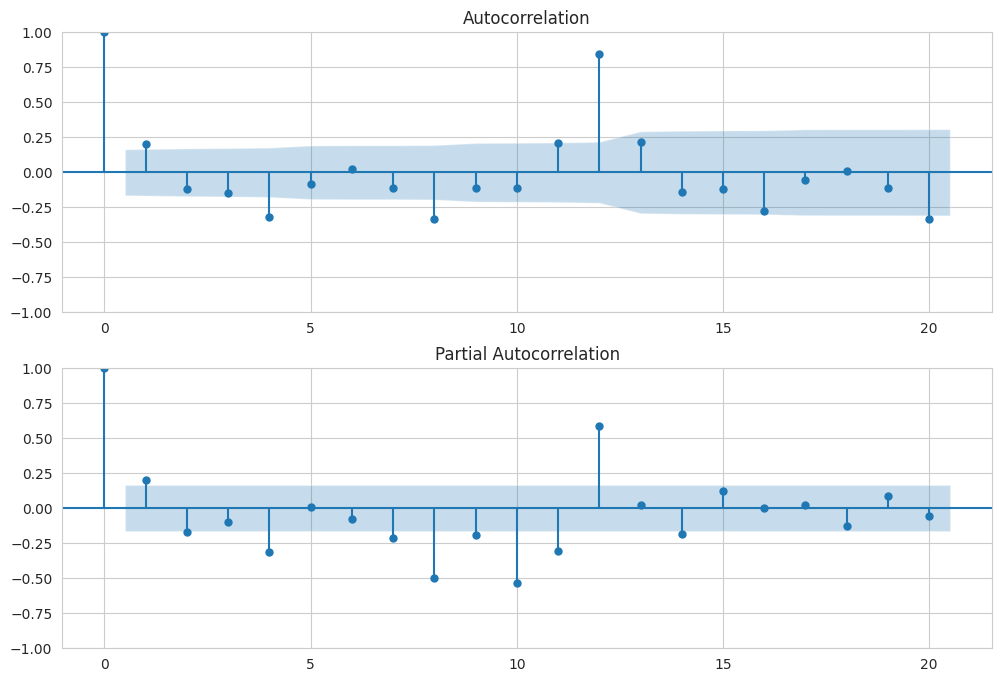

In [80]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize = (12, 8))
plt.subplot(2, 1, 1)
plot_acf(ts_log_diff, ax = plt.gca(), lags = 20)
plt.subplot(2, 1, 2)
plot_pacf(ts_log_diff, ax = plt.gca(), lags = 20)
plt.show()

ARIMA (Autoregressive Moving Average)

* AR Model - When p = 0
* MA Model - When q = 0
* No differencing d = 0 (Series is Stationary), d = 1 (Linear Trend) and Stong Trend / curve (d - 2)

In [81]:
from statsmodels.tsa.arima.model import ARIMA
# p = 0, 1, 2 ; q = 0, 1 ; d = 1
model = ARIMA(ts_log_diff, order = (1, 1,1))

In [82]:
result_model = model.fit()

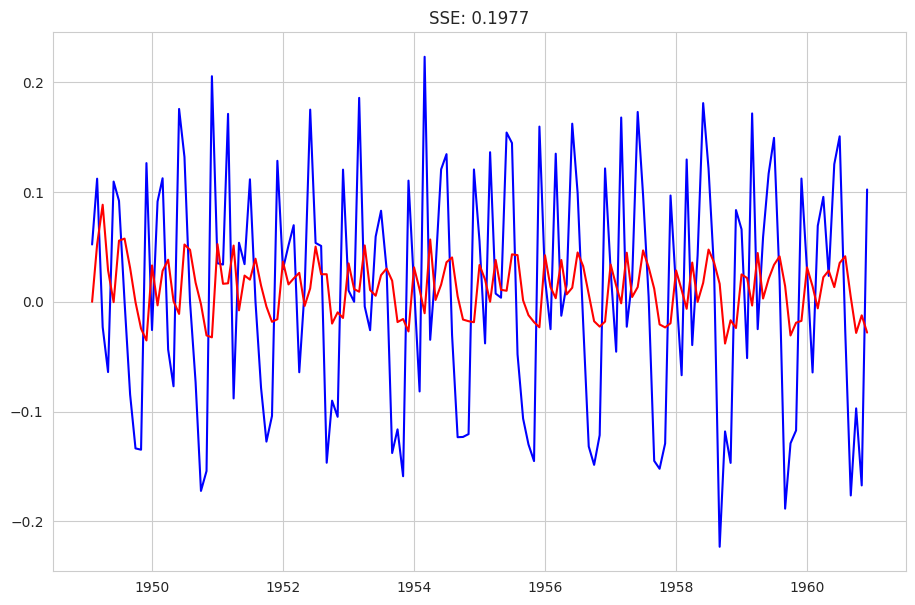

In [83]:
plt.plot(ts_log_diff, color = 'b')
plt.plot(result_model.fittedvalues, color = 'r')
sse = sum(result_model.fittedvalues - ts_log_diff)**2
plt.title('SSE: %.4f'%sse)
plt.show()

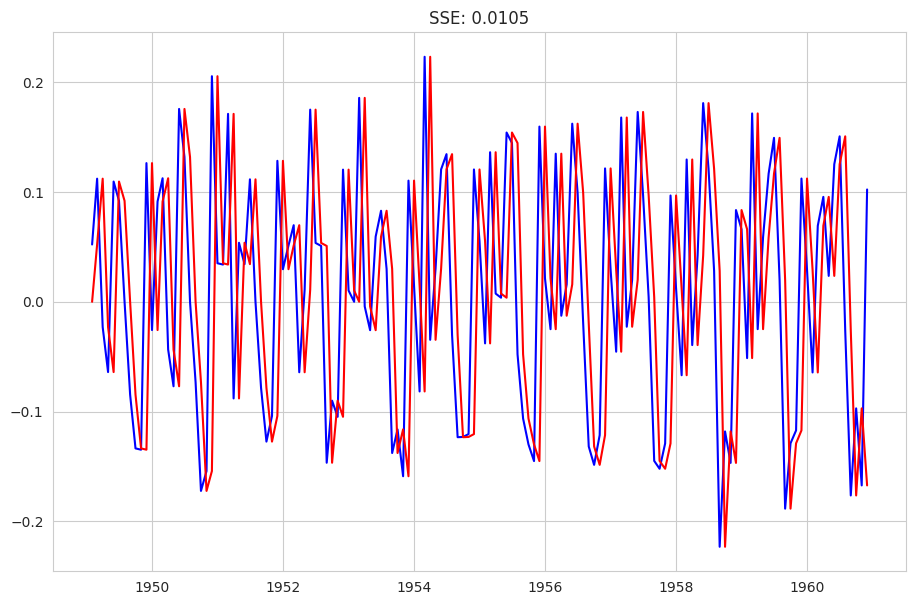

In [84]:
model = ARIMA(ts_log_diff, order = (0,1,0))
result_model = model.fit()
plt.plot(ts_log_diff, color = 'b')
plt.plot(result_model.fittedvalues, color = 'r')
sse = sum(result_model.fittedvalues - ts_log_diff)**2
plt.title('SSE: %.4f'%sse)
plt.show()

Text(0.5, 1.0, 'SSE: 0.0011')

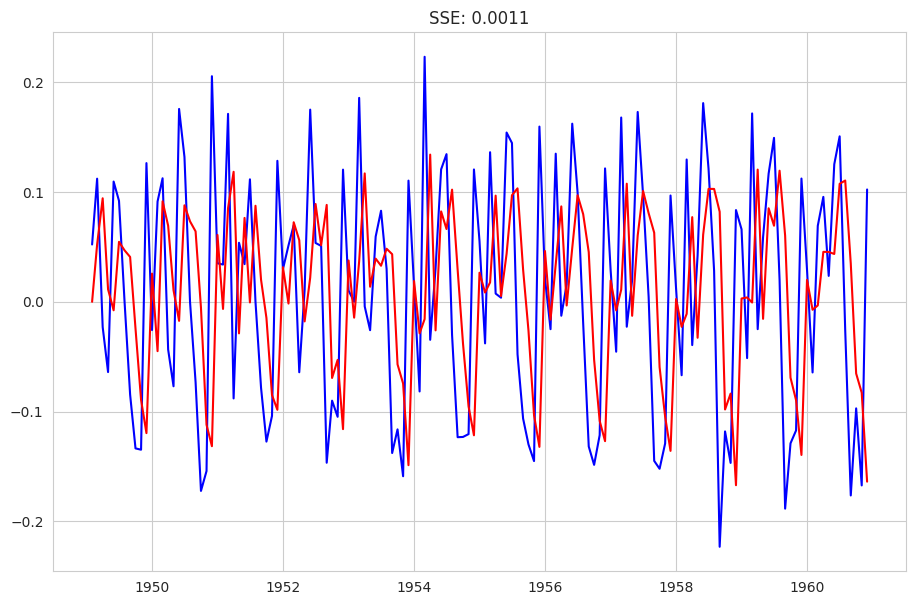

In [85]:
model = ARIMA(ts_log_diff, order = (2,1,0))
result_model = model.fit()
plt.plot(ts_log_diff, color = 'b', label = 'Actual' )
plt.plot(result_model.fittedvalues, color = 'r')
sse = sum(result_model.fittedvalues - ts_log_diff)**2
plt.title('SSE: %.4f'%sse)

In [86]:
train = data['#Passengers'][:120]
test = data['#Passengers'][120:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 120
Test Size: 24


In [87]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  120
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -541.534
Date:                Mon, 15 Jun 2026   AIC                           1093.069
Time:                        07:15:48   BIC                           1106.965
Sample:                    01-01-1949   HQIC                          1098.711
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6570      0.030     55.575      0.000       1.599       1.715
ar.L2         -0.9068      0.027    -33.739      0.000      -0.959      -0.854
ma.L1         -1.8842      0.058    -32.699      0.0

In [88]:
forecast = model_fit.forecast(steps=len(test))

forecast = pd.Series(forecast, index=test.index)

print(forecast.head())


Month
1959-01-01    336.928392
1959-02-01    348.740323
1959-03-01    368.377497
1959-04-01    390.205059
1959-05-01    408.566168
Name: predicted_mean, dtype: float64


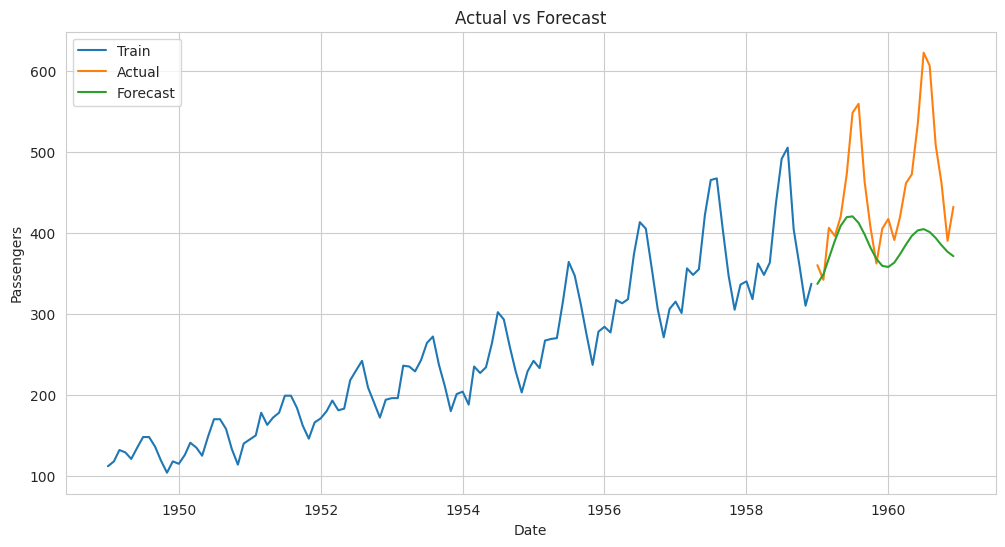

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast')

plt.title('Actual vs Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 69.09892054002972
RMSE: 90.69431415728216


In [91]:
final_model = ARIMA(data['#Passengers'], order=(2,1,2))
final_fit = final_model.fit()

future_forecast = final_fit.forecast(steps=12)

print(future_forecast)

1961-01-01    439.854863
1961-02-01    465.296545
1961-03-01    500.666051
1961-04-01    535.971401
1961-05-01    561.689094
1961-06-01    571.312667
1961-07-01    562.972100
1961-08-01    539.729052
1961-09-01    508.528057
1961-10-01    478.147364
1961-11-01    456.747520
1961-12-01    449.697306
Freq: MS, Name: predicted_mean, dtype: float64


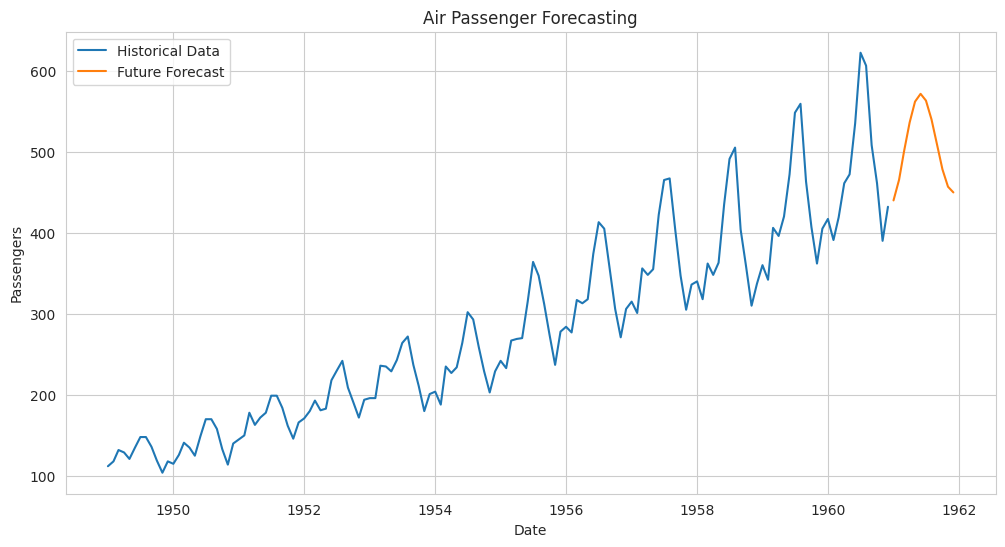

In [92]:
plt.figure(figsize=(12,6))

plt.plot(data['#Passengers'], label='Historical Data')
plt.plot(future_forecast, label='Future Forecast')

plt.title('Air Passenger Forecasting')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()

plt.show()